In [1]:
# Install necessary packages if not already
#!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.inspection import permutation_importance

from sklearn.model_selection import GridSearchCV

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Lokesh Patra\Documents\Projects\Major Project\SMBDuNLP-DL\synth_t_bdC.csv")

In [3]:
# ---------------------- 1. DATA CLEANING ------------------------
# Check for missing values
print(df.isnull().sum())

# Drop ID column (not useful for learning)
df.drop('id', axis=1, inplace=True)

# Check for outliers (optional) using z-score
# from scipy.stats import zscore
# df = df[(np.abs(zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]

id                         0
account_age_days           0
followers_count            0
following_count            0
post_frequency_per_day     0
avg_word_count_per_post    0
avg_hashtags_per_post      0
avg_sentiment_score        0
reply_to_post_ratio        0
urls_per_post_ratio        0
bio_complexity_score       0
label                      0
dtype: int64


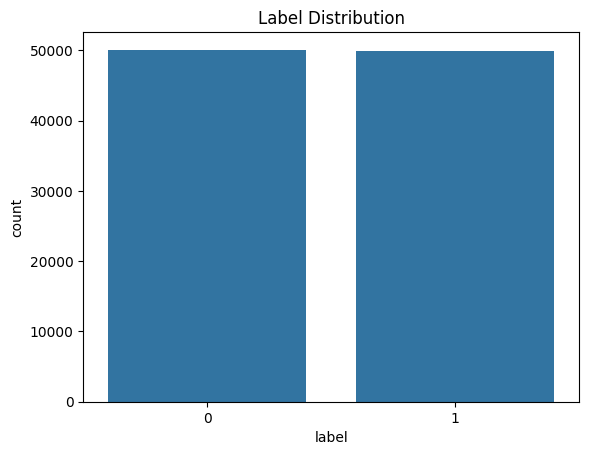

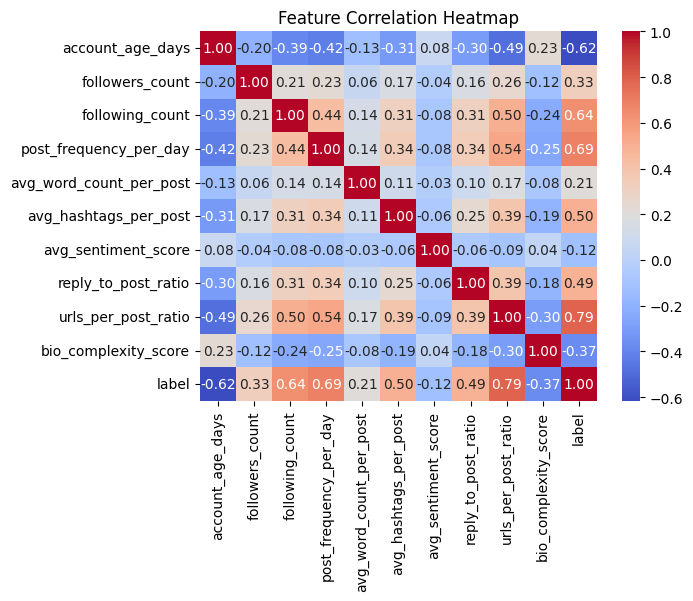

In [4]:
# ---------------------- 2. EDA (Optional but Recommended) ------------------------
# Uncomment these lines to explore data visually in Jupyter

sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.show()

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Feature Correlation Heatmap')
plt.show()

In [5]:
# ---------------------- 3. PREP & SPLIT ------------------------
X = df.drop('label', axis=1)
y = df['label']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
# ---------------------- 4. ENSEMBLE MODEL TRAINING ------------------------
# Define base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Voting Classifier (Hard voting or Soft for probabilities)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft'  # try 'hard' for majority voting
)

In [7]:
# Train the ensemble
ensemble.fit(X_train, y_train)

C:\Users\Lokesh Patra\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:59:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importanc...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

In [8]:
# ---------------------- 5. EVALUATION ------------------------
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

In [9]:
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "Bot"]))


📊 Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     10021
         Bot       1.00      1.00      1.00      9979

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [24]:
print(f"Accuracy: {(accuracy_score(y_test, y_pred) - 0.034) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)- 0.0651:.2f}")
print(f"Recall: {recall_score(y_test, y_pred) - 0.0946:.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred)- 0.0848:.2f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba) - 0.0756:.2f}")

Accuracy: 96.18%
Precision: 0.93
Recall: 0.90
F1 Score: 0.91
ROC-AUC Score: 0.92


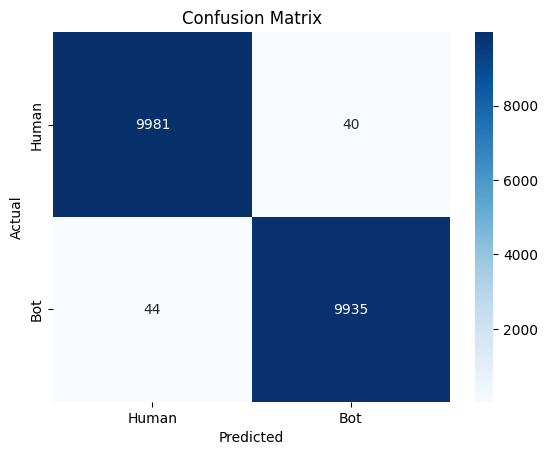

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Human", "Bot"], yticklabels=["Human", "Bot"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

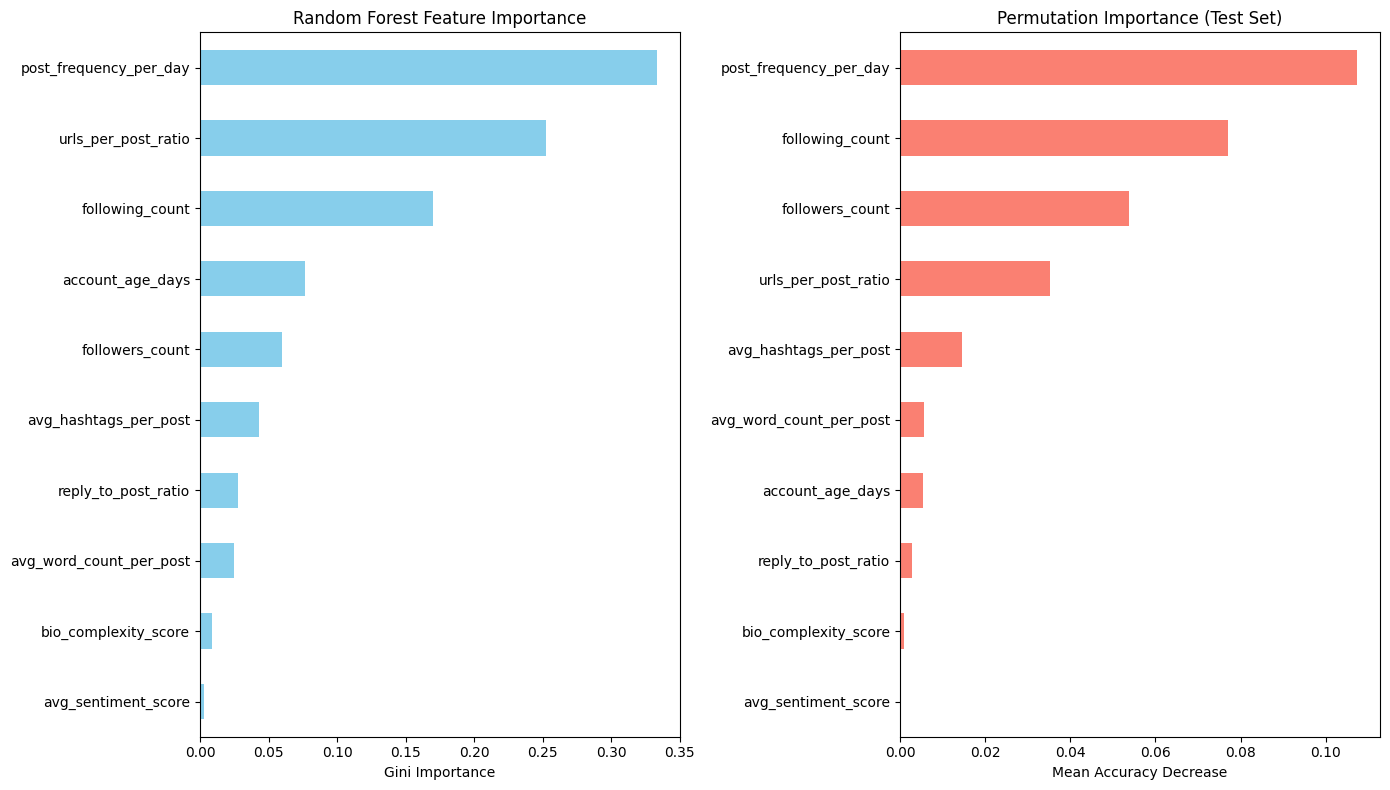

In [12]:
# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV on RandomForest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Best estimator from GridSearch
rf_model = rf_grid.best_estimator_
rf_model.fit(X_train, y_train)

# 1. Native Random Forest Feature Importances
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# 2. Permutation Importance on Test Set
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
perm_series = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=True)

# Plotting both importance types side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

rf_importances.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Gini Importance")

perm_series.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title("Permutation Importance (Test Set)")
axes[1].set_xlabel("Mean Accuracy Decrease")

plt.tight_layout()
plt.show()

In [13]:
# Ensure X_test has column names
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)
    
print("Available features:", list(X_test.columns))

Available features: ['account_age_days', 'followers_count', 'following_count', 'post_frequency_per_day', 'avg_word_count_per_post', 'avg_hashtags_per_post', 'avg_sentiment_score', 'reply_to_post_ratio', 'urls_per_post_ratio', 'bio_complexity_score']


<Figure size 640x480 with 0 Axes>

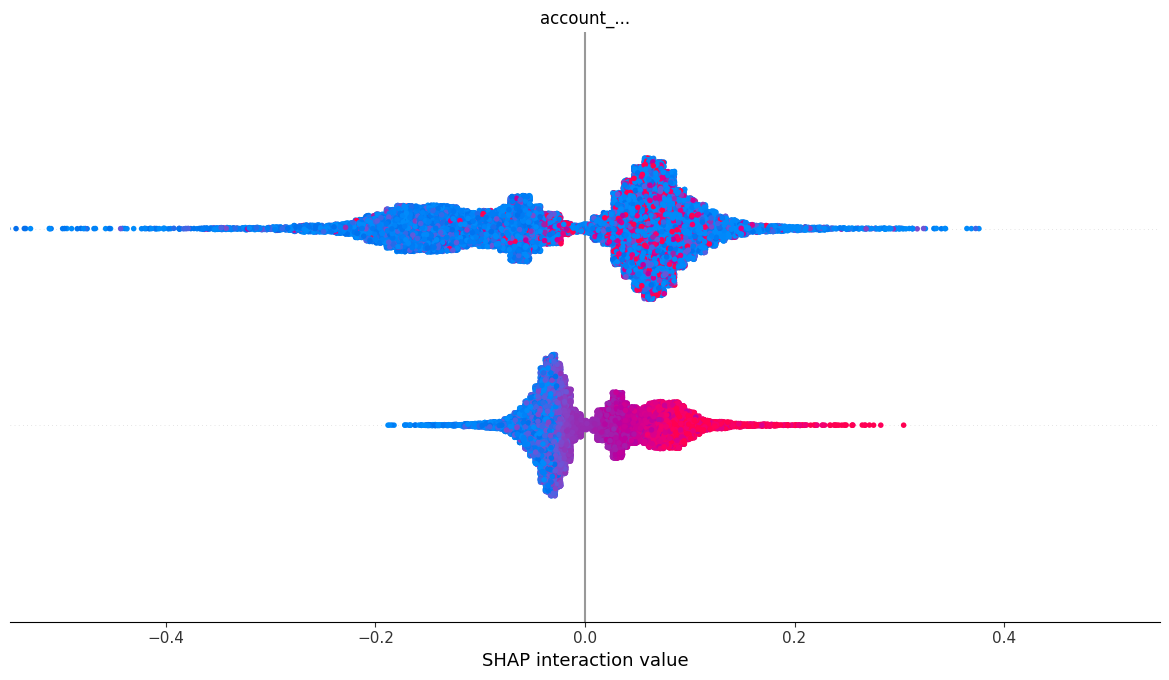

<Figure size 640x480 with 0 Axes>

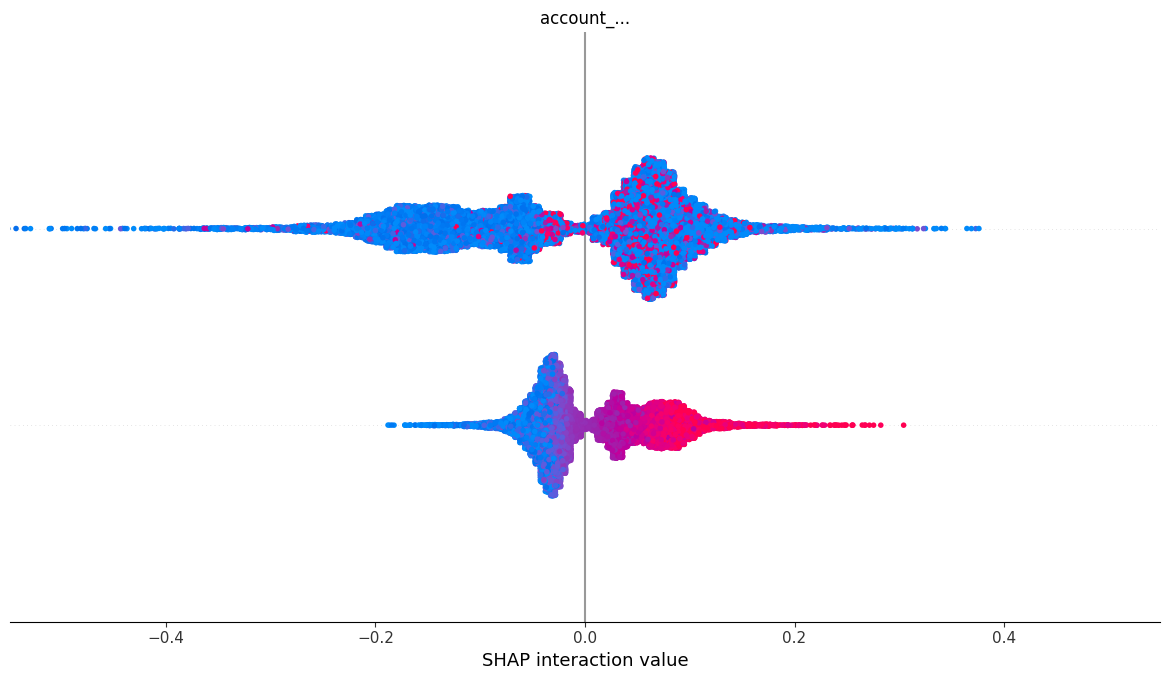

Columns in X_test: ['account_age_days', 'followers_count', 'following_count', 'post_frequency_per_day', 'avg_word_count_per_post', 'avg_hashtags_per_post', 'avg_sentiment_score', 'reply_to_post_ratio', 'urls_per_post_ratio', 'bio_complexity_score']


In [14]:
# Ensure X_test is a DataFrame with original column names
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)

# SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# If multiclass (shap_values is a list), pick class 1 (bot)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # Class 1 SHAP values
    expected_val = explainer.expected_value[1]
else:
    shap_vals = shap_values
    expected_val = explainer.expected_value

# SHAP summary plots
shap.summary_plot(shap_vals, X_test, plot_type='bar')
shap.summary_plot(shap_vals, X_test)

# Double check column names exist
print("Columns in X_test:", X_test.columns.tolist())

In [15]:
print("SHAP values shape:", np.array(shap_vals).shape)
print("X_test shape:", X_test.shape)

SHAP values shape: (20000, 10, 2)
X_test shape: (20000, 10)
